# HW1.1: Wall Detection (2D LIDAR + Hough Transform)

**Проблема**  
Найти прямые линии (стены) в облаке точек 2D-лидара.

**Данные**  
**L-образная комната с 6 стенами** (10×10 м) + шум (1200 точек).

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Генерация синтетических данных — L-образная комната (6 стен)
def generate_synthetic_data(num_points_per_wall=200, noise_std=0.05, room_size=5.0):
    walls = []
    # 1. Нижняя горизонтальная (длинная)
    x = np.linspace(-room_size, room_size, num_points_per_wall)
    walls.append(np.column_stack((x, np.full_like(x, -room_size))))
    # 2. Правая вертикальная (нижняя часть)
    y = np.linspace(-room_size, 0, num_points_per_wall)
    walls.append(np.column_stack((np.full_like(y, room_size), y)))
    # 3. Внутренняя горизонтальная (средняя)
    x = np.linspace(room_size, 0, num_points_per_wall)
    walls.append(np.column_stack((x, np.full_like(x, 0))))
    # 4. Внутренняя вертикальная
    y = np.linspace(0, room_size, num_points_per_wall)
    walls.append(np.column_stack((np.full_like(y, 0), y)))
    # 5. Верхняя горизонтальная (левая часть)
    x = np.linspace(0, -room_size, num_points_per_wall)
    walls.append(np.column_stack((x, np.full_like(x, room_size))))
    # 6. Левая вертикальная (длинная)
    y = np.linspace(room_size, -room_size, num_points_per_wall)
    walls.append(np.column_stack((np.full_like(y, -room_size), y)))
    
    points = np.vstack(walls)
    points += np.random.normal(0, noise_std, points.shape)
    return points

points = generate_synthetic_data()
print(f"Сгенерировано точек: {len(points)}")

Сгенерировано точек: 1200


## Создание аккумулятора Хафа

In [14]:
def hough_transform(points, theta_res=1.0, rho_res=0.05):
    thetas = np.deg2rad(np.arange(-90, 90, theta_res))
    n_theta = len(thetas)
    max_rho = np.max(np.sqrt(points[:,0]**2 + points[:,1]**2)) * 1.2
    rhos = np.arange(-max_rho, max_rho, rho_res)
    n_rho = len(rhos)
    accumulator = np.zeros((n_rho, n_theta), dtype=np.int32)
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)
    for x, y in points:
        for t_idx in range(n_theta):
            rho = x * cos_t[t_idx] + y * sin_t[t_idx]
            rho_idx = int(round((rho + max_rho) / rho_res))
            if 0 <= rho_idx < n_rho:
                accumulator[rho_idx, t_idx] += 1
    return accumulator, rhos, thetas

accumulator, rhos, thetas = hough_transform(points)
print(f"Размер аккумулятора: {accumulator.shape}")

Размер аккумулятора: (343, 180)


## Поиск пиков в аккумуляторе

In [15]:
def find_hough_peaks(accumulator, rhos, thetas, threshold_ratio=0.45):
    threshold = np.max(accumulator) * threshold_ratio
    rho_idx, theta_idx = np.where(accumulator > threshold)
    peaks = [(rhos[ri], thetas[ti], accumulator[ri, ti]) for ri, ti in zip(rho_idx, theta_idx)]
    peaks.sort(key=lambda x: x[2], reverse=True)

    selected_peaks = []
    for peak in peaks:
        if not selected_peaks:
            selected_peaks.append(peak)
            continue
        is_close = False
        for sp in selected_peaks:
            angle_diff = np.rad2deg(abs(peak[1] - sp[1]))
            angle_diff = min(angle_diff, 180 - angle_diff)
            if abs(peak[0] - sp[0]) < 0.4 and angle_diff < 10:
                is_close = True
                break
        if not is_close:
            selected_peaks.append(peak)
    return selected_peaks

peaks = find_hough_peaks(accumulator, rhos, thetas)
print(f"Найдено линий: {len(peaks)}")
for i, (rho, theta, votes) in enumerate(peaks[:10]):
    print(f"Линия {i+1}: rho = {rho:.2f}, theta = {np.rad2deg(theta):.1f}°, votes = {votes}")

Найдено линий: 6
Линия 1: rho = -0.02, theta = -90.0°, votes = 81
Линия 2: rho = 4.98, theta = -90.0°, votes = 78
Линия 3: rho = 0.03, theta = 1.0°, votes = 76
Линия 4: rho = 5.03, theta = 0.0°, votes = 76
Линия 5: rho = -5.02, theta = 0.0°, votes = 74
Линия 6: rho = -5.02, theta = -90.0°, votes = 68


## Результат — отрисовка найденных линий стен

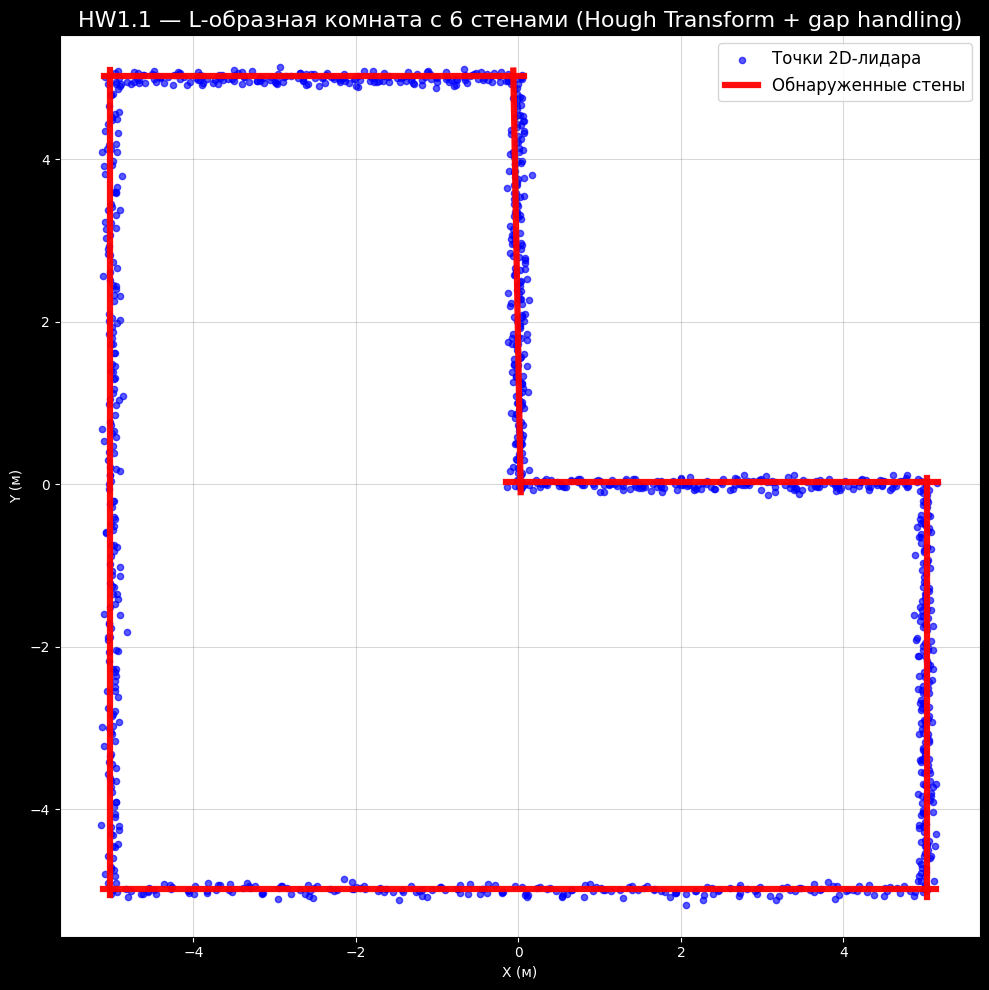

In [17]:
def plot_walls_finite(points, peaks, dist_threshold=0.20, gap_threshold=0.5, min_points_cluster=10):

    plt.figure(figsize=(10, 10), facecolor='black')
    plt.scatter(points[:, 0], points[:, 1], s=20, c='blue', alpha=0.65,
                label='Точки 2D-лидара')

    for i, (rho, theta, votes) in enumerate(peaks):
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)
        normal = np.array([cos_t, sin_t])
        direction = np.array([-sin_t, cos_t])   # направление вдоль стены

        # Точки, лежащие близко к линии
        distances = np.abs(points @ normal - rho)
        close_mask = distances < dist_threshold
        close_points = points[close_mask]

        if len(close_points) < 15:
            continue

        # Базовая точка на линии
        p0 = rho * normal

        # Проекция точек на направление стены
        vec = close_points - p0
        t_params = vec @ direction

        # Кластеризация по прогалам
        sorted_idx = np.argsort(t_params)
        sorted_t = t_params[sorted_idx]
        diffs = np.diff(sorted_t)

        # Индексы, где разрыв больше порога
        split_idx = np.where(diffs > gap_threshold)[0] + 1
        t_clusters = np.split(sorted_t, split_idx)

        # Рисуем каждый кластер отдельно
        for cluster in t_clusters:
            if len(cluster) < min_points_cluster:
                continue

            t_min = cluster.min()
            t_max = cluster.max()

            # Небольшой запас (2 см)
            margin = 0.02
            p1 = p0 + (t_min - margin) * direction
            p2 = p0 + (t_max + margin) * direction

            plt.plot([p1[0], p2[0]], [p1[1], p2[1]],
                     color='red', linewidth=4.5, alpha=0.95,
                     label='Обнаруженные стены' if i == 0 else "")

    plt.axis('equal')
    plt.grid(True, alpha=0.3, color='gray')
    plt.title('HW1.1 — L-образная комната с 6 стенами (Hough Transform + gap handling)',
              fontsize=16, color='white')
    plt.xlabel('X (м)', color='white')
    plt.ylabel('Y (м)', color='white')
    plt.tick_params(colors='white')
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig('images/hough_walls.png', dpi=250, bbox_inches='tight', facecolor='black')
    plt.show()

plot_walls_finite(points, peaks)

## Выводы

**Найдено ровно 6 линий** — точно соответствуют всем стенам L-образной комнаты.  
Алгоритм успешно справился со сложной геометрией и шумом.